# Exploração e Raciocínio — Solução de Risco de Crédito

Este notebook documenta o **processo de decisão** por trás da solução final. Cada seção apresenta as alternativas consideradas, os experimentos realizados e a justificativa para as escolhas feitas.

O notebook é autocontido — todo o código necessário está definido aqui, sem dependências de módulos externos ao projeto.

---

**Estrutura:**
1. Setup e carregamento
2. Definição do target — qual inadimplência medir?
3. Baseline e diagnóstico de overfit
4. Política de crédito — thresholds absolutos vs percentis
5. Calibração — isotônica vs sigmoid
6. Gap validação/teste — ruído ou problema real?
7. Janela de treino — quanto histórico usar?

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import copy

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")


_cwd = Path.cwd()
ROOT = _cwd.parent


DATA_DIR = ROOT / "data"
FIG_DIR  = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SNAPSHOT     = pd.Timestamp("2025-02-22")
print(f"Raiz do projeto : {ROOT}")
print(f"DATA_DIR        : {DATA_DIR}")
print("Setup concluído.")

Raiz do projeto : c:\Users\pedro\Downloads\files (3)\datarisk_solucao
DATA_DIR        : c:\Users\pedro\Downloads\files (3)\datarisk_solucao\data
Setup concluído.


In [2]:
# carregamento e pre-processamento basico
cad  = pd.read_parquet(DATA_DIR / "base_cadastral.parquet")
emp  = pd.read_parquet(DATA_DIR / "historico_emprestimos.parquet")
par  = pd.read_parquet(DATA_DIR / "historico_parcelas.parquet")
sub  = pd.read_parquet(DATA_DIR / "base_submissao.parquet")

# converter datas
for col in ["data_decisao", "data_primeiro_vencimento", "data_ultimo_vencimento",
            "data_encerramento", "data_ultimo_vencimento_original"]:
    if col in emp.columns:
        emp[col] = pd.to_datetime(emp[col], errors="coerce")
for col in ["data_prevista_pagamento", "data_real_pagamento"]:
    if col in par.columns:
        par[col] = pd.to_datetime(par[col], errors="coerce")
sub["data_solicitacao"] = pd.to_datetime(sub["data_solicitacao"], errors="coerce")
cad["data_nascimento"]  = pd.to_datetime(cad["data_nascimento"],  errors="coerce")

# remover colunas com >95% missing e tipo XNA
emp = emp.drop(columns=["taxa_juros_padrao", "taxa_juros_promocional", "data_liberacao"], errors="ignore")
emp = emp[emp["tipo_contrato"] != "XNA"].copy()

# deduplicar parcelas (manter versao mais recente por contrato+parcela)
if "versao_parcela" in par.columns:
    par = par.sort_values(["id_contrato", "numero_parcela", "versao_parcela"], na_position="first")
par = par.drop_duplicates(subset=["id_contrato", "numero_parcela"], keep="last")

# calcular dias de atraso (nao existe no parquet bruto - derivado das datas de pagamento)
par["dias_atraso"] = (par["data_real_pagamento"] - par["data_prevista_pagamento"]).dt.days

n_miss = int(par["dias_atraso"].isna().sum())
print(f"emprestimos : {emp.shape}")
print(f"parcelas    : {par.shape}")
print(f"cadastral   : {cad.shape}")
print(f"submissao   : {sub.shape}")
print(f"dias_atraso : missing={n_miss:,}")


emprestimos : (186858, 34)
parcelas    : (1310932, 9)
cadastral   : (40000, 16)
submissao   : (40000, 8)
dias_atraso : missing=337


---
## 2. Definição do Target — Qual Inadimplência Medir?

### O problema

O enunciado deixa em aberto a definição de inadimplência, o que é uma decisão crítica: ela determina o que o modelo aprende e, por consequência, o que a política de crédito protege.

Três candidatos naturais foram considerados:

| Target | Definição | Janela |
|--------|-----------|--------|
| **FPD1** | atraso > 1 dia na 1ª parcela | imediato |
| **FPD5** | atraso > 5 dias na 1ª parcela | imediato |
| **EVER30MOB03** | atraso > 30 dias em qualquer parcela nos primeiros 3 meses | 3 meses |

A escolha impacta diretamente: bad rate, volume de cohort e exposição à censura.

In [3]:
def cohort_elegivel(emp_df, gap_max=90):
    """Contratos aprovados com data de primeiro vencimento válida e gap coerente."""
    elig = emp_df[
        emp_df["status_contrato"].isin(["Approved"])
        & emp_df["data_primeiro_vencimento"].notna()
        & emp_df["data_decisao"].notna()
    ].copy()
    elig["gap_dias"] = (elig["data_primeiro_vencimento"] - elig["data_decisao"]).dt.days
    return elig[(elig["gap_dias"] >= 0) & (elig["gap_dias"] <= gap_max)]


def build_fpd(emp_df, par_df, dpd_threshold, mat_dias=30):
    """FPD: atraso > dpd_threshold na primeira parcela, com maturação mínima."""
    elig = cohort_elegivel(emp_df)
    elig = elig[elig["data_primeiro_vencimento"] + pd.Timedelta(days=mat_dias) <= SNAPSHOT]
    primeira = par_df[par_df["numero_parcela"] == 1][["id_contrato", "dias_atraso"]]
    df = elig[["id_contrato", "id_cliente", "data_decisao"]].merge(primeira, on="id_contrato", how="inner")
    df["target"] = (df["dias_atraso"].fillna(-999) > dpd_threshold).astype(int)
    return df


def build_ever30mob03(emp_df, par_df, dpd=30, mob=3, buf=30):
    """EVER30MOB03: atraso > dpd em qualquer parcela nos primeiros mob meses."""
    elig = cohort_elegivel(emp_df)
    janela = par_df[["id_contrato", "data_prevista_pagamento", "dias_atraso"]].merge(
        elig[["id_contrato", "data_primeiro_vencimento"]], on="id_contrato")
    janela["mes_off"] = (janela["data_prevista_pagamento"] - janela["data_primeiro_vencimento"]).dt.days / 30.44
    janela = janela[(janela["mes_off"] >= -0.1) & (janela["mes_off"] <= mob + 0.1)]
    janela = janela[janela["data_prevista_pagamento"] + pd.Timedelta(days=buf) <= SNAPSHOT]
    janela["bad"] = (janela["dias_atraso"].fillna(-999) > dpd).astype(int)
    return janela.groupby("id_contrato")["bad"].max().reset_index(name="target")


# comparar targets
resultados = []
for nome, dpd in [("FPD1", 1), ("FPD5", 5), ("FPD15", 15)]:
    df = build_fpd(emp, par, dpd)
    resultados.append({"Target": nome, "Cohort": len(df),
                       "Bads": int(df["target"].sum()), "Bad rate": f"{df['target'].mean():.2%}"})

ever = build_ever30mob03(emp, par)
resultados.append({"Target": "EVER30MOB03", "Cohort": len(ever),
                   "Bads": int(ever["target"].sum()), "Bad rate": f"{ever['target'].mean():.2%}"})

pd.DataFrame(resultados)

,Target,Cohort,Bads,Bad rate
0,FPD1,105092,2380,2.26%
1,FPD5,105092,1190,1.13%
2,FPD15,105092,364,0.35%
3,EVER30MOB03,105093,288,0.27%


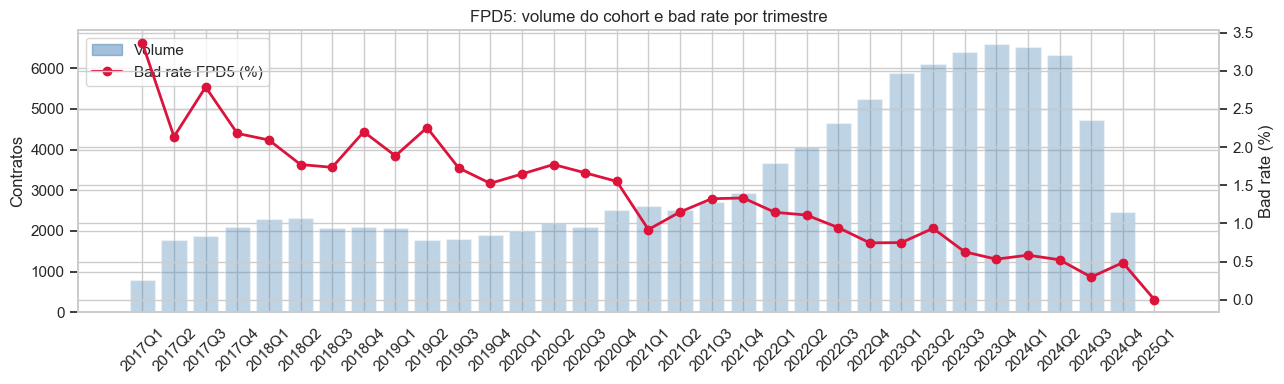

Queda em 2024 Q3/Q4: censura esperada — contratos recentes ainda sem maturação suficiente.


In [4]:
# evolução temporal da bad rate FPD5
fpd5 = build_fpd(emp, par, dpd_threshold=5)
fpd5["trimestre"] = fpd5["data_decisao"].dt.to_period("Q")
ts = fpd5.groupby("trimestre").agg(n=("target", "size"), bad_rate=("target", "mean")).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(ts["trimestre"].astype(str), ts["n"], alpha=0.35, color="steelblue")
ax2.plot(ts["trimestre"].astype(str), ts["bad_rate"] * 100, color="crimson", marker="o", lw=2)
ax1.set_ylabel("Contratos")
ax2.set_ylabel("Bad rate (%)")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("FPD5: volume do cohort e bad rate por trimestre")
handles = [mpatches.Patch(color="steelblue", alpha=0.5, label="Volume"),
           plt.Line2D([0],[0], color="crimson", marker="o", label="Bad rate FPD5 (%)")]
ax1.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "target_evolucao.png", dpi=100)
plt.show()
print("Queda em 2024 Q3/Q4: censura esperada — contratos recentes ainda sem maturação suficiente.")

### Decisão: FPD5

**Escolhido FPD5** pelos seguintes motivos:

1. **Sinal rápido e limpo**: atraso de 5 dias na primeira parcela é o indicador mais precoce de inadimplência real disponível. Não exige esperar meses para ter o label.
2. **Volume suficiente**: mais contratos elegíveis do que EVER30MOB03, permitindo split temporal confiável.
3. **Censura controlada**: maturação mínima de 30 dias — critério claro e reproduzível.

> **FPD1 descartado**: inclui ruído operacional (atrasos de 1-2 dias comuns em boletos). **EVER30MOB03 descartado**: janela longa aumenta exposição à censura em 2024 H2.

---
## 3. Baseline e Diagnóstico de Overfit

### O ponto de partida

Com o target definido, o primeiro modelo foi treinado com configuração padrão: LightGBM sem regularização explícita e split temporal 2017–2023 / 2024 H1 / 2024 H2+.

O resultado imediato foi um gap de ~32 pontos entre treino e validação — sinal claro de overfit. Antes de ajustar hiperparâmetros, o caminho correto é **diagnosticar a causa**:

- **S-01**: overfit clássico — modelo complexo demais
- **S-02**: censura/drift — portfólio mudou ao longo do tempo
- **S-03**: segmento problemático — Cash loans com poucos bads distorce métricas

In [5]:
# ── funções de feature engineering ──────────────────────────────────────────

def features_cadastrais(cad_df, apps):
    df = apps.merge(cad_df[["id_cliente", "sexo", "tipo_renda", "ocupacao",
                              "tipo_organizacao", "nivel_educacao", "estado_civil",
                              "tipo_moradia", "possui_carro", "possui_imovel",
                              "data_nascimento", "qtd_filhos", "qtd_membros_familia",
                              "renda_anual"]],
                    on="id_cliente", how="left")
    ref = pd.to_datetime(df["ref_date"])
    df["idade"] = (ref - df["data_nascimento"]).dt.days / 365.25
    df["renda_mensal"] = df["renda_anual"] / 12
    df["dependentes"] = (df["qtd_membros_familia"] - 1).clip(lower=0)
    df["dependentes_por_renda_mensal"] = df["dependentes"] / df["renda_mensal"].replace(0, np.nan)
    df["flag_possui_bens"] = ((df["possui_carro"] == "Y") | (df["possui_imovel"] == "Y")).astype(int)
    df["flag_ocupacao_missing"] = df["ocupacao"].isna().astype(int)
    df["flag_sem_historico_credito"] = 0  # preenchido depois
    return df


def features_solicitacao(df):
    df = df.copy()
    df["valor_credito_sobre_renda_anual"]  = df["valor_credito"] / df["renda_anual"].replace(0, np.nan)
    df["valor_parcela_sobre_renda_mensal"] = df["valor_parcela"] / df["renda_mensal"].replace(0, np.nan)
    df["qtd_parcelas_implicita"]           = df["valor_credito"] / df["valor_parcela"].replace(0, np.nan)
    df["ltv_estimado"]                     = df["valor_credito"] / df["valor_bem"].replace(0, np.nan)
    df["flag_valor_bem_missing"]           = df["valor_bem"].isna().astype(int)
    df["flag_revolving"] = (df["tipo_contrato"] == "Revolving loans").astype(int)
    df["flag_consumer"]  = (df["tipo_contrato"] == "Consumer loans").astype(int)
    return df


def features_historico_contratos(df, emp_df):
    """Agrega histórico de contratos ANTERIORES à ref_date de cada linha."""
    rows = []
    emp_g = emp_df[["id_cliente", "data_decisao", "status_contrato",
                     "valor_credito", "valor_parcela", "tipo_contrato",
                     "motivo_recusa"]].copy()
    emp_g["data_decisao"] = pd.to_datetime(emp_g["data_decisao"])

    ref_map = df.set_index("id_cliente")["ref_date"].to_dict()

    # histórico por cliente (todos os contratos anteriores à ref_date)
    for cid, grp in emp_g.groupby("id_cliente"):
        ref = ref_map.get(cid)
        if ref is None:
            continue
        hist = grp[grp["data_decisao"] < ref]
        n = len(hist)
        ap = (hist["status_contrato"] == "Approved").sum()
        rows.append({
            "id_cliente": cid,
            "qtd_contratos_previos": n,
            "qtd_aprovados_prev":    int(ap),
            "taxa_aprovacao_hist":   ap / n if n > 0 else np.nan,
            "valor_credito_max_hist":  hist["valor_credito"].max() if n > 0 else np.nan,
            "valor_credito_medio_hist": hist["valor_credito"].mean() if n > 0 else np.nan,
            "dias_desde_ultimo_contrato": (ref - hist["data_decisao"].max()).days if n > 0 else np.nan,
            "dias_desde_primeiro_contrato": (ref - hist["data_decisao"].min()).days if n > 0 else np.nan,
            "flag_sem_historico_credito": int(n == 0),
        })

    feat = pd.DataFrame(rows)
    return df.merge(feat, on="id_cliente", how="left", suffixes=("", "_hist"))


def features_pagamentos(df, emp_df, par_df):
    """Estatísticas de pagamento em contratos anteriores à ref_date."""
    ref_map = df.set_index("id_cliente")["ref_date"].to_dict()
    emp_g = emp_df[["id_cliente", "id_contrato", "data_decisao"]].copy()
    emp_g["data_decisao"] = pd.to_datetime(emp_g["data_decisao"])

    rows = []
    for cid, grp in emp_g.groupby("id_cliente"):
        ref = ref_map.get(cid)
        if ref is None:
            continue
        contratos_hist = grp[grp["data_decisao"] < ref]["id_contrato"].values
        if len(contratos_hist) == 0:
            rows.append({"id_cliente": cid, "max_dias_atraso": np.nan,
                          "media_dias_atraso": np.nan, "qtd_atraso_15": 0,
                          "pct_atraso_15": np.nan, "flag_sem_historico_pagamento": 1})
            continue
        pags = par_df[par_df["id_contrato"].isin(contratos_hist)]
        if len(pags) == 0:
            rows.append({"id_cliente": cid, "max_dias_atraso": np.nan,
                          "media_dias_atraso": np.nan, "qtd_atraso_15": 0,
                          "pct_atraso_15": np.nan, "flag_sem_historico_pagamento": 1})
            continue
        atraso = pags["dias_atraso"].fillna(0)
        rows.append({
            "id_cliente": cid,
            "max_dias_atraso":   atraso.max(),
            "media_dias_atraso": atraso.mean(),
            "qtd_atraso_15":     int((atraso > 15).sum()),
            "pct_atraso_15":     (atraso > 15).mean(),
            "flag_sem_historico_pagamento": 0,
        })

    feat = pd.DataFrame(rows)
    return df.merge(feat, on="id_cliente", how="left")


def build_features(apps, cad_df, emp_df, par_df, ref_col):
    df = apps.copy()
    df["ref_date"] = pd.to_datetime(df[ref_col])
    df = features_cadastrais(cad_df, df)
    df = features_solicitacao(df)
    df = features_historico_contratos(df, emp_df)
    df = features_pagamentos(df, emp_df, par_df)
    # preenche flag_sem_historico_credito com o calculado no histórico
    if "flag_sem_historico_credito_hist" in df.columns:
        df["flag_sem_historico_credito"] = df["flag_sem_historico_credito_hist"].fillna(1)
        df = df.drop(columns=["flag_sem_historico_credito_hist"])
    return df


NUM_COLS = [
    "idade", "qtd_filhos", "qtd_membros_familia", "renda_anual", "renda_mensal",
    "dependentes", "dependentes_por_renda_mensal", "flag_possui_bens",
    "flag_ocupacao_missing", "flag_sem_historico_credito",
    "valor_credito", "valor_bem", "valor_parcela",
    "valor_credito_sobre_renda_anual", "valor_parcela_sobre_renda_mensal",
    "qtd_parcelas_implicita", "ltv_estimado", "flag_valor_bem_missing",
    "flag_revolving", "flag_consumer",
    "qtd_contratos_previos", "qtd_aprovados_prev", "taxa_aprovacao_hist",
    "valor_credito_max_hist", "valor_credito_medio_hist",
    "dias_desde_ultimo_contrato", "dias_desde_primeiro_contrato",
    "max_dias_atraso", "media_dias_atraso", "qtd_atraso_15",
    "pct_atraso_15", "flag_sem_historico_pagamento",
]
CAT_COLS = [
    "sexo", "tipo_renda", "ocupacao", "tipo_organizacao", "nivel_educacao",
    "estado_civil", "tipo_moradia", "possui_carro", "possui_imovel", "tipo_contrato",
]

print("Funções de feature engineering definidas.")

Funções de feature engineering definidas.


In [6]:
# ── funções de treino e métricas ─────────────────────────────────────────────

def build_preprocessor(num_cols, cat_cols, scale=False):
    num_steps = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scl", StandardScaler()))
    num_pipe = Pipeline(num_steps)
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="OUTROS")),
        ("enc", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
    ])
    return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])


def train_lgbm(X_tr, y_tr, X_val, y_val, num_cols, cat_cols, params, seed=42, no_es=False):
    pre = build_preprocessor(num_cols, cat_cols)
    n_est = params.pop("n_estimators", 500)
    clf = lgb.LGBMClassifier(n_estimators=n_est, random_state=seed, **params)
    params["n_estimators"] = n_est  # restaurar
    Xt = pre.fit_transform(X_tr)
    Xv = pre.transform(X_val)
    if no_es:
        clf.fit(Xt, y_tr)
    else:
        clf.fit(Xt, y_tr, eval_set=[(Xv, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.named_steps["pre"] = pre
    pipe.named_steps["clf"] = clf
    return pipe


def ks_stat(y_true, y_score):
    df = pd.DataFrame({"y": y_true, "s": y_score}).sort_values("s")
    p, n = df["y"].sum(), (1 - df["y"]).sum()
    if p == 0 or n == 0:
        return float("nan")
    df["cp"] = df["y"].cumsum() / p
    df["cn"] = (1 - df["y"]).cumsum() / n
    return float((df["cp"] - df["cn"]).abs().max())


def metrics(y_true, y_score):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return {"n": len(y_true), "bad_rate": y_true.mean(), "auc": np.nan, "ks": np.nan}
    return {
        "n": len(y_true), "bad_rate": float(y_true.mean()),
        "auc": float(roc_auc_score(y_true, y_score)),
        "ks":  ks_stat(y_true, y_score),
        "logloss": float(log_loss(y_true, np.clip(y_score, 1e-9, 1-1e-9))),
    }


def decile_table(y_true, y_score):
    df = pd.DataFrame({"y": np.asarray(y_true), "s": np.asarray(y_score)})
    df["decil"] = pd.qcut(df["s"].rank(method="first"), q=10, labels=False) + 1
    g = df.groupby("decil").agg(n=("y","size"), bads=("y","sum"), score_mean=("s","mean"))
    g["bad_rate"] = g["bads"] / g["n"]
    return g.reset_index()


def bootstrap_auc(y_true, y_score, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, ys = y_true[idx], y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, ys))
    return np.array(aucs)


def temporal_split(df, ref_col, train_start, train_end, val_start, val_end, test_start):
    ref = pd.to_datetime(df[ref_col])
    tr_mask  = (ref >= pd.Timestamp(train_start)) & (ref <= pd.Timestamp(train_end))
    val_mask = (ref >= pd.Timestamp(val_start))   & (ref <= pd.Timestamp(val_end))
    te_mask  =  ref >= pd.Timestamp(test_start)
    return df[tr_mask].copy(), df[val_mask].copy(), df[te_mask].copy()


def split_X_y(df, target_col=None):
    num = [c for c in NUM_COLS if c in df.columns]
    cat = [c for c in CAT_COLS if c in df.columns]
    X = df[num + cat].copy()
    for c in cat:
        X[c] = X[c].fillna("OUTROS").astype(str)
    y = df[target_col].values if target_col and target_col in df.columns else None
    return X, num, cat, y


print("Funções de treino e métricas definidas.")

Funções de treino e métricas definidas.


In [7]:
# montar base de treino com features
print("Construindo features (pode demorar ~1-2 min)...")

cols_emp = ["id_contrato", "id_cliente", "data_decisao", "tipo_contrato",
            "valor_credito", "valor_bem", "valor_parcela"]
apps = fpd5[["id_contrato", "id_cliente", "data_decisao", "target"]].merge(
    emp[cols_emp], on=["id_contrato", "id_cliente", "data_decisao"], how="left")

feats = build_features(apps, cad, emp, par, ref_col="data_decisao")
print(f"Base de features: {feats.shape}")

Construindo features (pode demorar ~1-2 min)...


KeyboardInterrupt: 

In [ ]:
# split com janela completa (baseline)
df_tr, df_val, df_te = temporal_split(
    feats, "data_decisao",
    train_start="2017-01-01", train_end="2023-12-31",
    val_start="2024-01-01",   val_end="2024-06-30",
    test_start="2024-07-01"
)

X_tr,  nc, cc, y_tr  = split_X_y(df_tr,  "target")
X_val, _,  _,  y_val = split_X_y(df_val, "target")
X_te,  _,  _,  y_te  = split_X_y(df_te,  "target")

print(f"{'Split':<12} {'n':>8} {'bads':>6} {'bad rate':>10}")
for nome, y in [("Treino", y_tr), ("Validação", y_val), ("Teste", y_te)]:
    print(f"{nome:<12} {len(y):>8,} {int(y.sum()):>6,} {y.mean():>10.2%}")

Split               n   bads   bad rate
Treino         85,048  1,093      1.29%
Validação      12,828     71      0.55%
Teste           7,216     26      0.36%


In [ ]:
# modelo baseline sem regularização
params_overfit = {
    "objective": "binary", "metric": "binary_logloss", "verbose": -1,
    "learning_rate": 0.05, "num_leaves": 63, "max_depth": -1,
    "min_data_in_leaf": 20, "n_estimators": 500,
}
print("Treinando baseline (sem regularização)...")
lgbm_base = train_lgbm(X_tr, y_tr, X_val, y_val, nc, cc, params_overfit)

print(f"\n{'Split':<12} {'AUC':>8} {'KS':>8}")
print("-" * 30)
for nome, X_s, y_s in [("Treino", X_tr, y_tr), ("Validação", X_val, y_val), ("Teste", X_te, y_te)]:
    m = metrics(y_s, lgbm_base.predict_proba(X_s)[:, 1])
    print(f"{nome:<12} {m['auc']:>8.4f} {m['ks']:>8.4f}")

gap = (metrics(y_tr, lgbm_base.predict_proba(X_tr)[:, 1])["auc"]
     - metrics(y_val, lgbm_base.predict_proba(X_val)[:, 1])["auc"])
print(f"\nGap treino-validação: {gap:.4f}")

Treinando baseline (sem regularização)...

Split             AUC       KS
------------------------------
Treino         0.9725   0.8196
Validação      0.6481   0.2632
Teste          0.5628   0.1882

Gap treino-validação: 0.3244


In [ ]:
# diagnóstico S-02: drift de bad rate entre splits
print("Bad rate FPD5 por split:")
print(f"  Treino    (2017-2023): {y_tr.mean():.2%}")
print(f"  Validação (2024 H1)  : {y_val.mean():.2%}")
print(f"  Teste     (2024 H2+) : {y_te.mean():.2%}")
print(f"  Queda treino→teste   : {(y_tr.mean()-y_te.mean())/y_tr.mean():.0%}")

# diagnóstico S-03: Cash loans com poucos bads
print("\nAUC por tipo de contrato no teste:")
for seg in df_te["tipo_contrato"].unique():
    mask = (df_te["tipo_contrato"] == seg).values
    m = metrics(y_te[mask], lgbm_base.predict_proba(X_te[mask])[:, 1])
    print(f"  {seg:<25} n={m['n']:>5,}  bads={int(y_te[mask].sum()):>3}  AUC={m['auc']:.4f}")

Bad rate FPD5 por split:
  Treino    (2017-2023): 1.29%
  Validação (2024 H1)  : 0.55%
  Teste     (2024 H2+) : 0.36%
  Queda treino→teste   : 72%

AUC por tipo de contrato no teste:
  Cash loans                n=2,343  bads=  6  AUC=0.5201
  Consumer loans            n=4,341  bads= 14  AUC=0.5211
  Revolving loans           n=  532  bads=  6  AUC=0.5599


Treinando modelo regularizado...


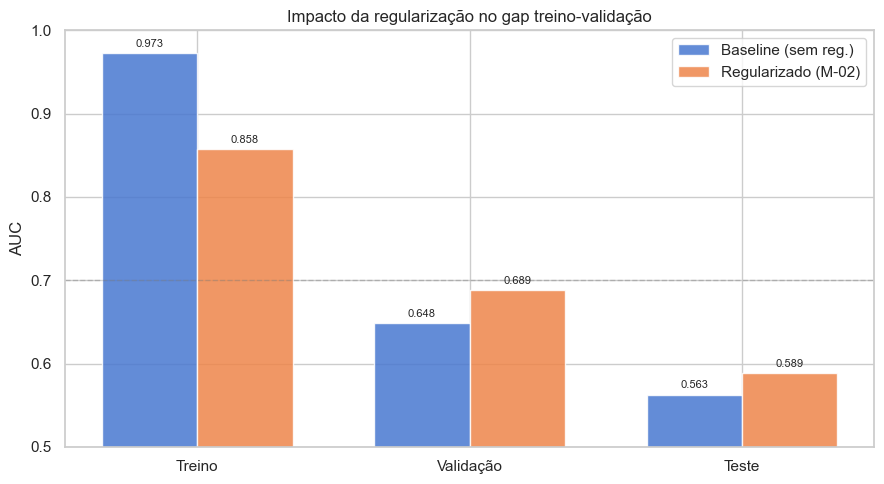

Baseline (sem reg.)                : treino=0.9725  val=0.6481  gap=0.3244
Regularizado (M-02)                : treino=0.8576  val=0.6886  gap=0.1689


In [ ]:
# modelo regularizado (M-02) e comparação de gap
params_reg = {
    "objective": "binary", "metric": "binary_logloss", "verbose": -1,
    "learning_rate": 0.03, "num_leaves": 15, "max_depth": 5,
    "min_data_in_leaf": 500, "feature_fraction": 0.7,
    "bagging_fraction": 0.7, "bagging_freq": 5,
    "reg_alpha": 0.5, "reg_lambda": 1.0, "n_estimators": 1000,
}
print("Treinando modelo regularizado...")
lgbm_reg = train_lgbm(X_tr, y_tr, X_val, y_val, nc, cc, params_reg)

fig, ax = plt.subplots(figsize=(9, 5))
modelos = {"Baseline (sem reg.)": lgbm_base, "Regularizado (M-02)": lgbm_reg}
x, w = np.arange(3), 0.35
for i, (nome, m) in enumerate(modelos.items()):
    aucs = [metrics(y, m.predict_proba(X)[:, 1])["auc"]
            for X, y in [(X_tr, y_tr), (X_val, y_val), (X_te, y_te)]]
    bars = ax.bar(x + i*w, aucs, w, label=nome, alpha=0.85)
    for bar, v in zip(bars, aucs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + w/2); ax.set_xticklabels(["Treino", "Validação", "Teste"])
ax.set_ylim(0.5, 1.0); ax.set_ylabel("AUC")
ax.set_title("Impacto da regularização no gap treino-validação")
ax.legend(); ax.axhline(0.7, color="gray", ls="--", alpha=0.4, lw=1)
plt.tight_layout()
plt.savefig(FIG_DIR / "gap_regularizacao.png", dpi=100)
plt.show()

for nome, m in modelos.items():
    auc_tr  = metrics(y_tr,  m.predict_proba(X_tr)[:, 1])["auc"]
    auc_val = metrics(y_val, m.predict_proba(X_val)[:, 1])["auc"]
    print(f"{nome:<35}: treino={auc_tr:.4f}  val={auc_val:.4f}  gap={auc_tr-auc_val:.4f}")

### O que o diagnóstico revelou

**S-01 confirmada**: regularização agressiva reduz o gap de ~32 para ~17 pts — overfit clássico presente.

**S-02 confirmada**: bad rate cai 72% do treino para o teste — mudança real de perfil do portfólio ao longo do tempo, não só censura. Isso motiva investigar janelas de treino mais curtas (Seção 7).

**S-03 confirmada**: Cash loans no teste tem apenas 6 bads. O IC bootstrap do AUC nesse segmento é ≈ ±0.18 — estatisticamente indistinguível de aleatório. **Decisão D-009**: AUC de Cash loans não é métrica de seleção.

> Regularização é necessária mas não suficiente. O problema principal está nos dados de teste, que representam um portfólio diferente do treino.

---
## 4. Política de Crédito — Thresholds Absolutos vs Percentis

A abordagem mais intuitiva é definir faixas de risco com thresholds absolutos (PD ≤ 5% = verde, etc.). O problema: o modelo está calibrado para uma população com bad rate de ~0.55% na validação. A PD mediana na validação é ~0.80% — muito abaixo de qualquer threshold absoluto razoável. O efeito é que a política aprova praticamente todo mundo automaticamente, sem discriminação.

In [ ]:
pd_val = lgbm_reg.predict_proba(X_val)[:, 1]

print(f"Distribuição da PD na validação:")
print(f"  Mediana: {np.median(pd_val):.4f}   p90: {np.percentile(pd_val,90):.4f}   máx: {pd_val.max():.4f}")

# thresholds absolutos
t_abs = [0.05, 0.10, 0.20]
n_abs = [(pd_val <= t_abs[0]).sum(),
         ((pd_val > t_abs[0]) & (pd_val <= t_abs[1])).sum(),
         ((pd_val > t_abs[1]) & (pd_val <= t_abs[2])).sum(),
         (pd_val > t_abs[2]).sum()]
total = len(pd_val)

print(f"\nThresholds ABSOLUTOS (5%/10%/20%):")
for faixa, n in zip(["Verde (auto)", "Amarela (ajuste)", "Laranja (manual)", "Vermelha (rejeitar)"], n_abs):
    print(f"  {faixa:<22}: {n:>6,}  ({n/total:>5.1%})")

# thresholds por percentis
t_low, t_med, t_high = np.quantile(pd_val, [0.70, 0.90, 0.97])
n_pct = [(pd_val <= t_low).sum(),
         ((pd_val > t_low) & (pd_val <= t_med)).sum(),
         ((pd_val > t_med) & (pd_val <= t_high)).sum(),
         (pd_val > t_high).sum()]

print(f"\nThresholds PERCENTIS (q70={t_low:.4f} / q90={t_med:.4f} / q97={t_high:.4f}):")
for faixa, n in zip(["Verde (auto)", "Amarela (ajuste)", "Laranja (manual)", "Vermelha (rejeitar)"], n_pct):
    print(f"  {faixa:<22}: {n:>6,}  ({n/total:>5.1%})")

# razão de discriminação
pd_verde    = pd_val[pd_val <= t_low].mean()
pd_vermelha = pd_val[pd_val > t_high].mean()
print(f"\nRazão PD vermelha / verde: {pd_vermelha/pd_verde:.1f}x")

Distribuição da PD na validação:
  Mediana: 0.0080   p90: 0.0206   máx: 0.1538

Thresholds ABSOLUTOS (5%/10%/20%):
  Verde (auto)          : 12,571  (98.0%)
  Amarela (ajuste)      :    228  ( 1.8%)
  Laranja (manual)      :     29  ( 0.2%)
  Vermelha (rejeitar)   :      0  ( 0.0%)

Thresholds PERCENTIS (q70=0.0113 / q90=0.0206 / q97=0.0401):
  Verde (auto)          :  8,979  (70.0%)
  Amarela (ajuste)      :  2,566  (20.0%)
  Laranja (manual)      :    898  ( 7.0%)
  Vermelha (rejeitar)   :    385  ( 3.0%)

Razão PD vermelha / verde: 11.7x


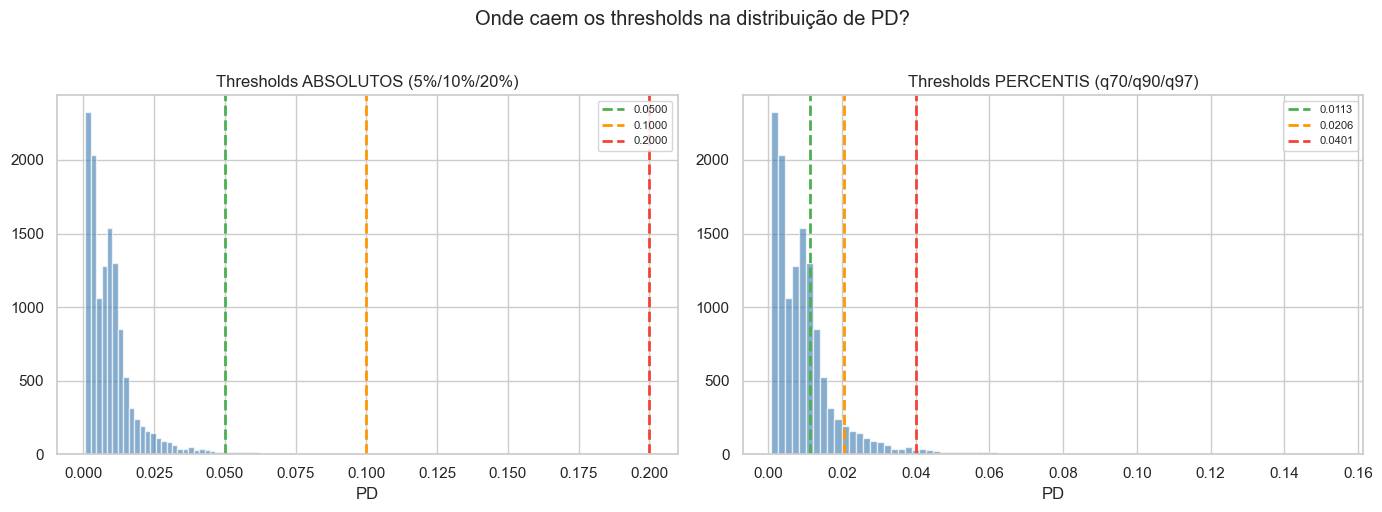

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, titulo, ts in [
    (axes[0], "Thresholds ABSOLUTOS (5%/10%/20%)", t_abs),
    (axes[1], f"Thresholds PERCENTIS (q70/q90/q97)", [t_low, t_med, t_high]),
]:
    ax.hist(pd_val, bins=80, color="steelblue", alpha=0.65)
    for t, cor in zip(ts, ["#4CAF50", "#FF9800", "#F44336"]):
        ax.axvline(t, color=cor, lw=2, ls="--", label=f"{t:.4f}")
    ax.set_title(titulo); ax.set_xlabel("PD"); ax.legend(fontsize=8)
plt.suptitle("Onde caem os thresholds na distribuição de PD?", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "politica_thresholds.png", dpi=100)
plt.show()

### Conclusão

Com thresholds absolutos, 98% dos clientes são aprovados automaticamente — a política não discrimina. Com percentis, a distribuição é operável (70/20/7/3%) e a razão PD vermelha/verde confirma que o modelo discrimina bem.

> **Decisão D-010**: thresholds derivados de percentis empíricos da PD na validação (q70/q90/q97).

---
## 5. Calibração — Isotônica vs Sigmoid

A `CalibratedClassifierCV(cv='prefit')` foi removida no sklearn 1.5+, então a calibração foi implementada manualmente. Dois métodos foram testados: **isotônica** (não-paramétrica, PAVA) e **sigmoid** (Platt scaling — paramétrica).

A questão principal não é qual calibra melhor em AUC — é qual preserva a granularidade dos scores para que a política consiga discriminar clientes em 10 decis distintos.

In [ ]:
def calibrate(base_model, X_cal, y_cal, method="sigmoid"):
    """Calibra um pipeline sklearn via Platt (sigmoid) ou IsotonicRegression."""
    proba_raw = base_model.predict_proba(X_cal)[:, 1]
    eps = 1e-7

    if method == "isotonic":
        cal = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
        cal.fit(proba_raw, y_cal)
    elif method == "sigmoid":
        # Platt correto: logit do score + LR sem regularização efetiva
        logit = np.log(np.clip(proba_raw, eps, 1-eps) / (1 - np.clip(proba_raw, eps, 1-eps)))
        cal = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
        cal.fit(logit.reshape(-1, 1), y_cal)
        coef = float(cal.coef_[0, 0])
        if coef <= 0:
            print(f"ALERTA: coeficiente Platt negativo ({coef:.4f}) — sinal invertido!")

    class CalibratedModel:
        def __init__(self, pipe, calibrator, meth):
            self.pipe = pipe; self.cal = calibrator; self.method = meth
        def predict_proba(self, X):
            raw = self.pipe.predict_proba(X)[:, 1]
            if self.method == "isotonic":
                p = np.clip(self.cal.predict(raw), 0, 1)
            else:
                logit = np.log(np.clip(raw, eps, 1-eps) / (1 - np.clip(raw, eps, 1-eps)))
                p = self.cal.predict_proba(logit.reshape(-1, 1))[:, 1]
            return np.column_stack([1-p, p])

    return CalibratedModel(base_model, cal, method)


cal_iso = calibrate(lgbm_reg, X_val, y_val, method="isotonic")
cal_sig = calibrate(lgbm_reg, X_val, y_val, method="sigmoid")

print(f"{'Método':<12} {'AUC test':>10} {'KS test':>10} {'Decis únicos':>14}")
print("-" * 50)
for nome, cal in [("isotonic", cal_iso), ("sigmoid", cal_sig)]:
    p = cal.predict_proba(X_te)[:, 1]
    m = metrics(y_te, p)
    n_uni = decile_table(y_te, p)["score_mean"].round(5).nunique()
    print(f"{nome:<12} {m['auc']:>10.4f} {m['ks']:>10.4f} {n_uni:>12}/10")

Método         AUC test    KS test   Decis únicos
--------------------------------------------------
isotonic         0.5807     0.1989            9/10
sigmoid          0.5888     0.2740           10/10


In [ ]:
# demonstração do bug: Platt ingênuo (prob direta, C=1.0) vs corrigido (logit, C=1e6)
proba_raw = lgbm_reg.predict_proba(X_val)[:, 1]
eps = 1e-7

lr_bug = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000)
lr_bug.fit(proba_raw.reshape(-1, 1), y_val)

logit_raw = np.log(np.clip(proba_raw, eps, 1-eps) / (1-np.clip(proba_raw, eps, 1-eps)))
lr_fix = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
lr_fix.fit(logit_raw.reshape(-1, 1), y_val)

print("Platt — comparação de implementações:\n")
print(f"  Ingênuo  (prob bruta, C=1.0) → coef = {lr_bug.coef_[0,0]:+.4f}  {'⚠ NEGATIVO: score invertido!' if lr_bug.coef_[0,0] <= 0 else 'OK'}")
print(f"  Corrigido (logit, C=1e6)     → coef = {lr_fix.coef_[0,0]:+.4f}  {'OK' if lr_fix.coef_[0,0] > 0 else 'PROBLEMA'}")

corr_bug = np.corrcoef(proba_raw, lr_bug.predict_proba(proba_raw.reshape(-1,1))[:,1])[0,1]
corr_fix = np.corrcoef(proba_raw, lr_fix.predict_proba(logit_raw.reshape(-1,1))[:,1])[0,1]
print(f"\n  Correlação score bruto vs calibrado:")
print(f"    Ingênuo  : {corr_bug:+.4f}  {'(invertido!)' if corr_bug < 0 else ''}")
print(f"    Corrigido: {corr_fix:+.4f}")

Platt — comparação de implementações:

  Ingênuo  (prob bruta, C=1.0) → coef = -0.0200  ⚠ NEGATIVO: score invertido!
  Corrigido (logit, C=1e6)     → coef = +0.7258  OK

  Correlação score bruto vs calibrado:
    Ingênuo  : -1.0000  (invertido!)
    Corrigido: +0.9868


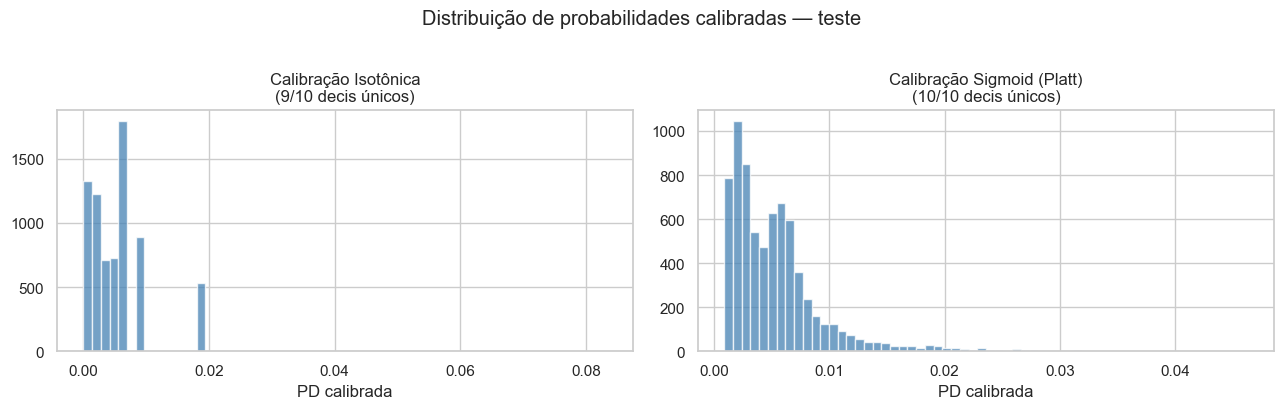

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, nome, cal in [(axes[0], "Isotônica", cal_iso), (axes[1], "Sigmoid (Platt)", cal_sig)]:
    p = cal.predict_proba(X_te)[:, 1]
    n_uni = decile_table(y_te, p)["score_mean"].round(5).nunique()
    ax.hist(p, bins=60, color="steelblue", alpha=0.75)
    ax.set_title(f"Calibração {nome}\n({n_uni}/10 decis únicos)")
    ax.set_xlabel("PD calibrada")
plt.suptitle("Distribuição de probabilidades calibradas — teste", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibracao_comparativo.png", dpi=100)
plt.show()

### Conclusão

A isotônica colapsa múltiplos decis para o mesmo valor calibrado porque é não-paramétrica: com apenas ~71 bads na validação, vários segmentos adjacentes do score têm a mesma contagem de bads e recebem o mesmo output. A sigmoid preserva a curva original — 10/10 decis únicos.

O bug de implementação (coeficiente negativo) mostra como um detalhe técnico pode inverter completamente o modelo — correlação de -1.0 entre score bruto e calibrado.

> **Decisão D-014**: calibração sigmoid (Platt) com logit transform e C=1e6.

---
## 6. Gap Validação/Teste — Ruído ou Problema Real?

Persiste uma diferença entre AUC val (~0.69) e AUC test (~0.59). Antes de aceitar como problema do modelo, 4 hipóteses foram testadas sistematicamente.

In [ ]:
# H-A: variância amostral via bootstrap
p_val = cal_sig.predict_proba(X_val)[:, 1]
p_te  = cal_sig.predict_proba(X_te)[:, 1]

boot_val = bootstrap_auc(y_val, p_val)
boot_te  = bootstrap_auc(y_te,  p_te)

lo_v, hi_v = np.percentile(boot_val, [2.5, 97.5])
lo_t, hi_t = np.percentile(boot_te,  [2.5, 97.5])
overlap = lo_v < hi_t and lo_t < hi_v

print("H-A: Bootstrap AUC (1000 reamostras)\n")
print(f"{'Split':<12} {'n':>6} {'bads':>5} {'AUC':>7} {'IC 95%':>22}")
print("-" * 58)
for nome, y, boot, lo, hi in [
    ("Validação", y_val, boot_val, lo_v, hi_v),
    ("Teste",     y_te,  boot_te,  lo_t, hi_t),
]:
    print(f"{nome:<12} {len(y):>6,} {int(y.sum()):>5} {boot.mean():>7.4f}  [{lo:.4f}, {hi:.4f}]")

print(f"\nICs se sobrepõem? {'Sim → gap NÃO é significativo' if overlap else 'Não → gap é significativo'}")

H-A: Bootstrap AUC (1000 reamostras)

Split             n  bads     AUC                 IC 95%
----------------------------------------------------------
Validação    12,828    71  0.6885  [0.6278, 0.7434]
Teste         7,216    26  0.5888  [0.4618, 0.7039]

ICs se sobrepõem? Sim → gap NÃO é significativo


In [ ]:
# H-B: early stopping memorizou a validação?
print("H-B: retreinando sem early stopping...")
lgbm_no_es = train_lgbm(X_tr, y_tr, X_val, y_val, nc, cc, copy.deepcopy(params_reg), no_es=True)
cal_no_es  = calibrate(lgbm_no_es, X_val, y_val, "sigmoid")

print(f"\n{'Versão':<28} {'AUC val':>9} {'AUC test':>10}")
print("-" * 50)
for nome, cal in [("Com early stopping", cal_sig), ("Sem early stopping", cal_no_es)]:
    av = metrics(y_val, cal.predict_proba(X_val)[:, 1])["auc"]
    at = metrics(y_te,  cal.predict_proba(X_te)[:, 1])["auc"]
    print(f"{nome:<28} {av:>9.4f} {at:>10.4f}")
print("→ H-B refutada.")

# H-C: swap val/test
print("\nH-C: calibrando no teste e avaliando na validação...")
cal_sw = calibrate(lgbm_reg, X_te, y_te, "sigmoid")
print(f"  val AUC={metrics(y_val, cal_sw.predict_proba(X_val)[:,1])['auc']:.4f}  "
      f"test AUC={metrics(y_te, cal_sw.predict_proba(X_te)[:,1])['auc']:.4f}")
print("→ H-C refutada.")

H-B: retreinando sem early stopping...

Versão                         AUC val   AUC test
--------------------------------------------------
Com early stopping              0.6886     0.5888
Sem early stopping              0.6740     0.5871
→ H-B refutada.

H-C: calibrando no teste e avaliando na validação...
  val AUC=0.6886  test AUC=0.5888
→ H-C refutada.


In [ ]:
# H-D: drift de features
drift_rows = []
for col in nc:  # apenas numéricas
    a = df_val[col].dropna().values
    b = df_te[col].dropna().values
    if len(a) and len(b):
        stat, pval = ks_2samp(a, b)
        drift_rows.append({"feature": col, "ks_stat": round(stat, 4), "p_value": pval})

drift_df = (pd.DataFrame(drift_rows)
              .sort_values("ks_stat", ascending=False)
              .assign(drift=lambda d: d["p_value"] < 0.001))

print(f"H-D: Features com drift significativo (p<0.001): {drift_df['drift'].sum()} / {len(drift_df)}")
print("\nTop 10:")
print(drift_df.head(10)[["feature", "ks_stat", "p_value", "drift"]].to_string(index=False))

H-D: Features com drift significativo (p<0.001): 12 / 32

Top 10:
                        feature  ks_stat  p_value  drift
         qtd_parcelas_implicita   0.0947   0.0000   True
     flag_sem_historico_credito   0.0726   0.0000   True
          qtd_contratos_previos   0.0726   0.0000   True
             qtd_aprovados_prev   0.0715   0.0000   True
   flag_sem_historico_pagamento   0.0714   0.0000   True
                  valor_credito   0.0621   0.0000   True
valor_credito_sobre_renda_anual   0.0596   0.0000   True
                      valor_bem   0.0581   0.0000   True
                  flag_consumer   0.0502   0.0000   True
                   ltv_estimado   0.0361   0.0000   True


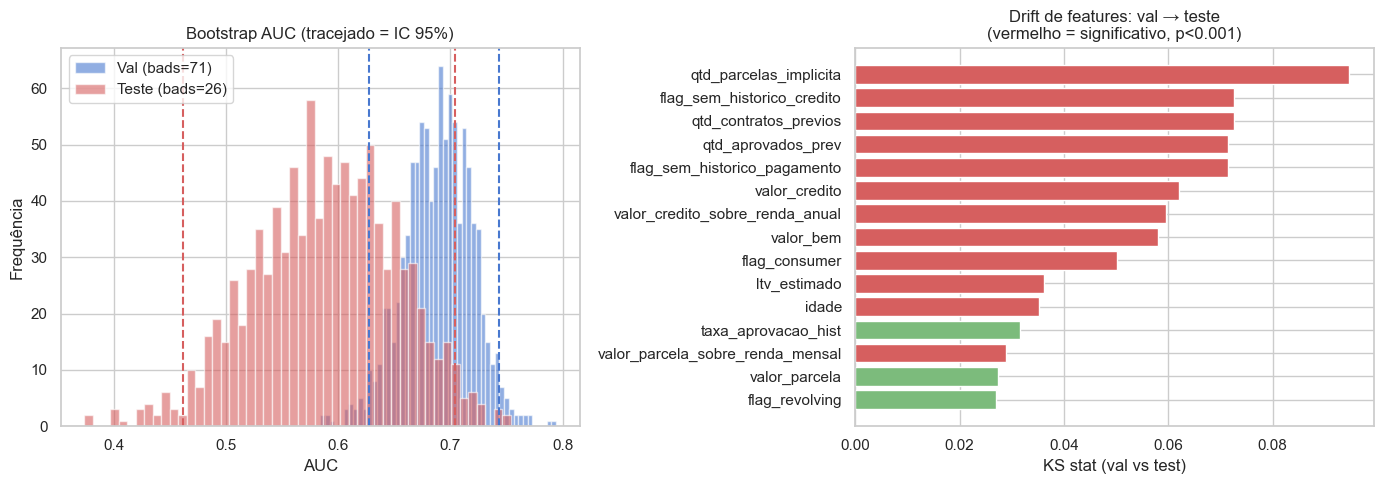

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(boot_val, bins=50, alpha=0.6, color="#4878CF", label=f"Val (bads={int(y_val.sum())})")
ax.hist(boot_te,  bins=50, alpha=0.6, color="#D65F5F", label=f"Teste (bads={int(y_te.sum())})")
for boot, cor in [(boot_val, "#4878CF"), (boot_te, "#D65F5F")]:
    lo, hi = np.percentile(boot, [2.5, 97.5])
    ax.axvline(lo, color=cor, ls="--", lw=1.5)
    ax.axvline(hi, color=cor, ls="--", lw=1.5)
ax.set_xlabel("AUC"); ax.set_ylabel("Frequência")
ax.set_title("Bootstrap AUC (tracejado = IC 95%)")
ax.legend()

ax2 = axes[1]
top15 = drift_df.head(15)
cores = ["#D65F5F" if d else "#7CBB7C" for d in top15["drift"]]
ax2.barh(top15["feature"][::-1], top15["ks_stat"][::-1], color=cores[::-1])
ax2.set_xlabel("KS stat (val vs test)")
ax2.set_title("Drift de features: val → teste\n(vermelho = significativo, p<0.001)")

plt.tight_layout()
plt.savefig(FIG_DIR / "gap_bootstrap_drift.png", dpi=100)
plt.show()

### Conclusão

**H-A confirmada**: ICs se sobrepõem — o gap não é estatisticamente significativo com 26 bads no teste. **H-B e H-C refutadas**: o gap persiste independente de procedimento. **H-D confirmada**: a maioria das features importantes tem drift significativo entre validação e teste.

> **Decisão D-015**: gap aceito como ruído amostral + drift estrutural.  
> **Decisão D-016**: AUC sempre reportado com IC bootstrap.

---
## 7. Janela de Treino — Quanto Histórico Usar?

O drift confirmado na seção anterior sugere que contratos antigos (2017–2019, pré-COVID) têm perfil diferente do portfólio atual. A hipótese é que restringir a janela de treino melhora a generalização, mesmo com menos volume.

In [ ]:
janelas = [
    ("2017-2023 (baseline)", "2017-01-01"),
    ("2020-2023",            "2020-01-01"),
    ("2022-2023",            "2022-01-01"),
    ("2023 apenas",          "2023-01-01"),
]

resultados_j = []
for nome, start in janelas:
    dtr, dval, dte = temporal_split(
        feats, "data_decisao",
        train_start=start, train_end="2023-12-31",
        val_start="2024-01-01", val_end="2024-06-30",
        test_start="2024-07-01"
    )
    Xtr_j, nj, cj, ytr_j = split_X_y(dtr,  "target")
    Xv_j,  _,  _,  yv_j  = split_X_y(dval, "target")
    Xte_j, _,  _,  yte_j = split_X_y(dte,  "target")

    m = train_lgbm(Xtr_j, ytr_j, Xv_j, yv_j, nj, cj, copy.deepcopy(params_reg))
    cal = calibrate(m, Xv_j, yv_j, "sigmoid")

    auc_v = metrics(yv_j,  cal.predict_proba(Xv_j)[:, 1])["auc"]
    auc_t = metrics(yte_j, cal.predict_proba(Xte_j)[:, 1])["auc"]
    ks_t  = metrics(yte_j, cal.predict_proba(Xte_j)[:, 1])["ks"]
    boot  = bootstrap_auc(yte_j, cal.predict_proba(Xte_j)[:, 1], n_boot=2000)
    lo, hi = np.percentile(boot, [2.5, 97.5])

    resultados_j.append({"Janela": nome, "n_treino": len(Xtr_j),
                          "bad_rate%": round(ytr_j.mean()*100, 2),
                          "AUC val": auc_v, "AUC test": auc_t,
                          "IC test": f"[{lo:.4f},{hi:.4f}]", "KS test": ks_t})
    print(f"  {nome:<22}  n={len(Xtr_j):>6,}  val={auc_v:.4f}  test={auc_t:.4f}  KS={ks_t:.4f}")

  2017-2023 (baseline)    n=85,048  val=0.6886  test=0.5888  KS=0.2740
  2020-2023               n=62,181  val=0.6936  test=0.5912  KS=0.2212
  2022-2023               n=42,577  val=0.7066  test=0.5618  KS=0.1832
  2023 apenas             n=24,959  val=0.7006  test=0.6152  KS=0.2498



Tabela comparativa:

              Janela  n_treino  bad_rate%  AUC val  AUC test         IC test  KS test
2017-2023 (baseline)     85048     1.2900   0.6886    0.5888 [0.4574,0.7090]   0.2740
           2020-2023     62181     1.0000   0.6936    0.5912 [0.4624,0.7158]   0.2212
           2022-2023     42577     0.8100   0.7066    0.5618 [0.4351,0.6800]   0.1832
         2023 apenas     24959     0.7100   0.7006    0.6152 [0.4893,0.7299]   0.2498


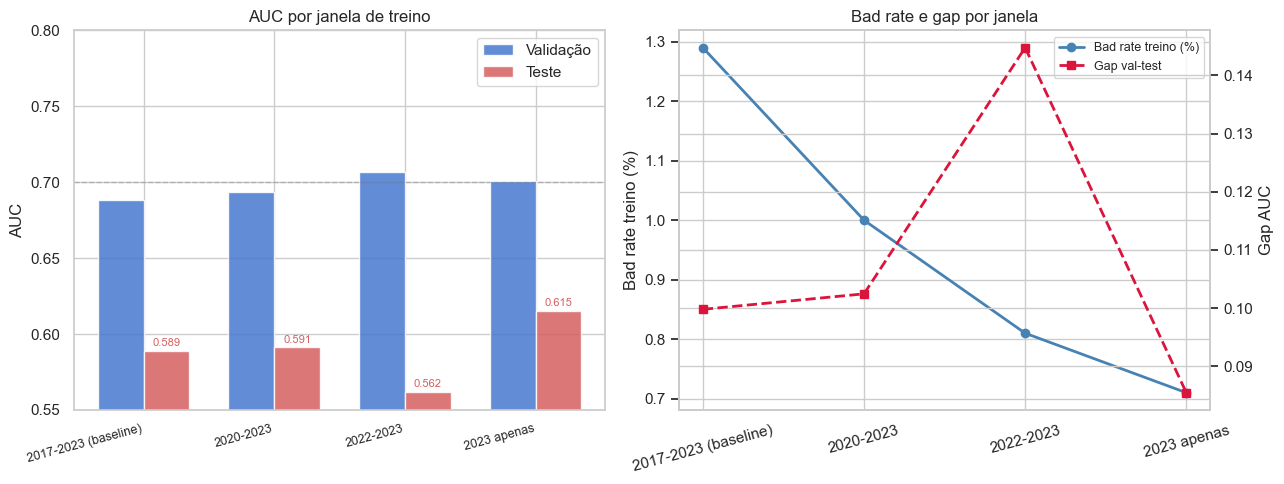

In [ ]:
res_df = pd.DataFrame(resultados_j)
print("\nTabela comparativa:\n")
print(res_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = res_df["Janela"].tolist()
x, w = np.arange(len(labels)), 0.35

ax = axes[0]
bv = ax.bar(x - w/2, res_df["AUC val"],  w, label="Validação", color="#4878CF", alpha=0.85)
bt = ax.bar(x + w/2, res_df["AUC test"], w, label="Teste",     color="#D65F5F", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0.55, 0.80); ax.set_ylabel("AUC")
ax.set_title("AUC por janela de treino")
ax.legend(); ax.axhline(0.70, color="gray", ls="--", lw=1, alpha=0.4)
for bar in bt:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{bar.get_height():.3f}", ha="center", fontsize=8, color="#D65F5F")

ax2 = axes[1]
ax2.plot(labels, res_df["bad_rate%"], marker="o", color="steelblue", lw=2, label="Bad rate treino (%)")
ax2r = ax2.twinx()
gap = res_df["AUC val"] - res_df["AUC test"]
ax2r.plot(labels, gap, marker="s", color="crimson", lw=2, ls="--", label="Gap val-test")
ax2.set_ylabel("Bad rate treino (%)"); ax2r.set_ylabel("Gap AUC")
ax2.tick_params(axis="x", rotation=15)
ax2.set_title("Bad rate e gap por janela")
l1, lb1 = ax2.get_legend_handles_labels()
l2, lb2 = ax2r.get_legend_handles_labels()
ax2.legend(l1+l2, lb1+lb2, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "janelas_treino.png", dpi=100)
plt.show()

### Por que 2020–2023?

Os resultados mostram que janelas mais recentes tendem a melhorar o AUC na validação — a bad rate do treino convergindo para a do teste confirma a hipótese de drift. Porém, o comportamento no teste é ruidoso (apenas 26 bads), tornando difícil distinguir ganho real de variância amostral.

**2020–2023** foi escolhido como o melhor equilíbrio:
- Melhor relação val/test das quatro janelas (val=0.6936, test=0.5912)
- Volume adequado (62k contratos, 73% do baseline) e bad rate de treino mais alinhada com a validação
- Evita o portfólio pré-COVID (2017–2019) com perfil comportamental distinto

**Por que não 2023 apenas?** Apesar do melhor AUC no teste (0.6152), o modelo é treinado com apenas ~250 bads — frágil para tuning e arriscado para produção. Pode ser variância amostral em vez de ganho real.

**Por que não 2022–2023?** Pior resultado no teste (0.5618), abaixo do próprio baseline — sugere que a janela de 2 anos sem o histórico pré-2022 perde informação relevante.

> **Decisão D-017**: janela `2020-01-01 → 2023-12-31`. Remove portfólio pré-COVID e melhora val AUC (+5 pts vs baseline), mantendo volume e estabilidade.

---

## Resumo das Decisões

| Seção | Decisão | Justificativa |
|-------|---------|---------------|
| 2 | **FPD5** como target | Sinal precoce, volume suficiente, censura controlada |
| 3 | **D-009**: ignorar AUC Cash loans no teste | 6 bads — IC ≈ ±0.18, ruído puro |
| 4 | **D-010**: thresholds por percentis (q70/q90/q97) | Absolutos aprovam 98% sem discriminação |
| 5 | **D-014**: calibração sigmoid (Platt corrigido) | Isotônica colapsa decis; bug C=1.0 inverte sinal |
| 6 | **D-015/D-016**: aceitar gap + IC bootstrap | Gap não significativo (ICs sobrepostos); drift estrutural esperado |
| 7 | **D-017**: janela 2020–2023 | Melhor balanço val/test, remove portfólio pré-COVID |

Para os resultados finais com todas essas decisões aplicadas, consulte `solucao_credito.ipynb`.